# Pandas y Valores Faltandes




## Wine Reviews dataset

Vamos a trabajar con el siguiente dataset, que corresponde a reviews de vinos:

https://www.kaggle.com/zynicide/wine-reviews/downloads/wine-reviews.zip/4

Por favor leer su descripción y, cuando tengan tiempo, mirar algunos de los "kernels" que pueden encontrar en Kaggle.

1. Abrir el dataset e imprimir sus primeras instancias.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
wine_reviews = pd.read_csv(r"/content/drive/MyDrive/cursos-para-dictar/UDM/03_clase/wine_reviews.csv")
wine_reviews.head(2)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos


2. ¿Cuántas columnas (features) tiene?¿Cuáles son sus nombres?¿Y cuántas filas (instancias)? Luego, descartar la columna `'Unnamed: 0'`.

In [5]:
print(wine_reviews.shape)
print(wine_reviews.columns)

(129971, 14)
Index(['Unnamed: 0', 'country', 'description', 'designation', 'points',
       'price', 'province', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='object')


In [6]:
wine_reviews.drop(columns=["Unnamed: 0"], inplace= True)

In [7]:
print(wine_reviews.shape)
print(wine_reviews.columns)

(129971, 13)
Index(['country', 'description', 'designation', 'points', 'price', 'province',
       'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title',
       'variety', 'winery'],
      dtype='object')


3. ¿Cuántos valores faltantes hay en cada columna?

In [8]:
wine_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  object 
 1   description            129971 non-null  object 
 2   designation            92506 non-null   object 
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  object 
 6   region_1               108724 non-null  object 
 7   region_2               50511 non-null   object 
 8   taster_name            103727 non-null  object 
 9   taster_twitter_handle  98758 non-null   object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 12.9+ MB


In [9]:
wine_reviews.isna().sum()

,0
country,63
description,0
designation,37465
points,0
price,8996
province,63
region_1,21247
region_2,79460
taster_name,26244
taster_twitter_handle,31213


4. ¿Cuál o cuáles son los vinos con más valores faltantes?

En pandas el parámetro axis define la dirección en la que se aplica una operación, y puede ser algo confuso al principio. Aquí te explico:

`axis=0` significa que la operación se aplica a lo largo de las filas (verticalmente), y el resultado se agrupa por columna. Por ejemplo, si haces df.sum(axis=0), sumarás cada columna (cada suma resulta de "bajar" por las filas).

`axis=1` significa que la operación se aplica a lo largo de las columnas (horizontalmente), y el resultado se agrupa por fila. Por ejemplo, df.sum(axis=1) suma los valores en cada fila (cada suma resulta de "moverse" a través de las columnas).

**En pandas, el parámetro axis determina la dirección en la que se aplica una operación:**

`axis=0:` La operación se aplica a lo largo de las filas, es decir, se calcula por cada columna.

`axis=1:` La operación se aplica a lo largo de las columnas, es decir, se calcula por cada fila.

El método `.idxmax()` devuelve el índice (label) de la primera aparición del valor máximo en una serie o columna de un DataFrame.

In [10]:
wine_reviews.isna().sum(axis = 1).idxmax()

86909

In [11]:
wine_reviews.iloc[wine_reviews.isna().sum(axis = 1).idxmax()]

,86909
country,Chile
description,"A chalky, dusty mouthfeel nicely balances this..."
designation,NaN
points,88
price,17.0
province,Maipo Valley
region_1,NaN
region_2,NaN
taster_name,NaN
taster_twitter_handle,NaN


5. Hacerse alguna pregunta acerca del dataset e intentar responderla. Por ejemplo, ¿cuáles son el peor y el mejor vino? Imprimir en pantalla sus características y su descripción. ¿Hay un solo vino que sea el mejor o el peor?

El script hace lo siguiente:

* `wine_reviews.points.max()`: Encuentra el valor máximo en la columna "points" del DataFrame wine_reviews.

* `wine_reviews[wine_reviews["points"] == wine_reviews.points.max()]`: Filtra el DataFrame para quedarse solo con las filas donde el valor de "points" es igual al valor máximo encontrado.

* `len(...)`: Calcula la cantidad de filas (es decir, el número de reseñas de vino) que tienen la puntuación máxima.

In [12]:
len(wine_reviews[wine_reviews["points"] == wine_reviews.points.max()])

19

In [13]:
wine_reviews.iloc[wine_reviews.points.idxmax()]

,345
country,Australia
description,This wine contains some material over 100 year...
designation,Rare
points,100
price,350.0
province,Victoria
region_1,Rutherglen
region_2,NaN
taster_name,Joe Czerwinski
taster_twitter_handle,@JoeCz


In [14]:
wine_reviews.iloc[wine_reviews.points.idxmin()]

,344
country,Chile
description,"Aromas of pumpkin, squash and corn chips are s..."
designation,Gran Reserva
points,80
price,19.0
province,Leyda Valley
region_1,NaN
region_2,NaN
taster_name,Michael Schachner
taster_twitter_handle,@wineschach


In [15]:
len(wine_reviews[wine_reviews["points"] == wine_reviews.points.min()])

397

## Trabajando con datos faltantes

Antes de realizar cada una de las siguientes consignas, recordá copiar el dataset en una nueva variable, así mantemos el dataset original sin modificar.

1. Descartar aquellas filas que tengan algún valor faltante. ¿Cuántas instancias quedan en el dataset?

In [16]:
len(wine_reviews)

129971

In [17]:
wine_reviews_copia = wine_reviews.copy()

In [18]:
wine_reviews_copia.dropna(inplace = True)
wine_reviews_copia.shape

(22387, 13)

2. Descartar aquellas columnas que tengan algún valor faltante. ¿Cuántos y cuáles atributos quedaron?

In [19]:
wine_reviews_copia = wine_reviews.copy()
wine_reviews_copia.shape

(129971, 13)

In [20]:
wine_reviews_copia.dropna(axis=1, inplace = True)
wine_reviews_copia.shape

(129971, 4)

Pueden observar que descartar sin ningún criterio puede hacer que perdamos muchos datos.

Tratemos de mejorar un poco los criterios con los que descartamos.

3. Descartar aquellas filas que tengan más de tres valores faltantes. ¿Cuántas instancias quedaron?

In [21]:
wine_reviews.reset_index(inplace=True)
wine_reviews_copia = wine_reviews.copy()
wine_reviews_copia.shape

(129971, 14)

In [22]:
wine_reviews_copia.dropna(thresh=11, inplace = True)
wine_reviews_copia.shape

(124924, 14)

4. Descartar aquellas columnas que tengan más del 50% de valores faltantes. ¿Cuántos y cuáles atributos quedaron? Luego, descartar las instancias que tengan algún valor faltante.

In [23]:
wine_reviews_copia = wine_reviews.copy()
wine_reviews.shape

(129971, 14)

In [24]:
wine_reviews_copia.shape[0]*0.5

64985.5

In [25]:
wine_reviews_copia.dropna(axis =1, inplace = True, thresh= wine_reviews_copia.shape[0] * 0.5)
wine_reviews_copia.shape

(129971, 13)

In [26]:
wine_reviews_copia.dropna(inplace = True)
wine_reviews_copia.shape

(52106, 13)

**Moraleja**: el orden importa. Primero, podemos descartar aquellas columnas con muchos valores faltantes y después descartar aquellas instancias con valores faltantes.

**Para pensar:** ¿de qué tipo son las variables del dataset?¿Es lo mismo un valor faltante en `price` que en `variety`?


## Imputación de Valores Faltantes

La columna `price` tiene alrededor de 9 mil valores faltantes, pero no queremos descartarla ni descartar instancias por el simple hecho de que no sepamos su precio. Esto se debe a que el precio tiene mucha información y, eventualmente, puede ser la columna que querramos predecir. Además, no son tantos valores faltantes si consideramos la cantidad de instancias que tiene el dataset. Entonces:


1. Calcular el valor medio, moda, mediana y la desviación estándar de la columna `price`.

In [ ]:
print(wine_reviews.price.mean())
print(wine_reviews.price.mode()[0]) # porque devuelve una serie que puede contener más de un valor. Con el 0 garantizo que solo devuelva el primero
print(wine_reviews.price.median())
print(wine_reviews.price.std())

35.363389129985535
20.0
25.0
41.02221766808723


In [ ]:
wine_reviews["price"].max()

3300.0

(array([5.700e+01, 5.530e+02, 2.231e+03, 5.497e+03, 7.483e+03, 9.281e+03,
        6.600e+03, 7.699e+03, 8.172e+03, 5.072e+03, 8.631e+03, 2.899e+03,
        4.329e+03, 5.227e+03, 2.631e+03, 4.870e+03, 1.919e+03, 2.652e+03,
        4.066e+03, 1.403e+03, 8.970e+02, 3.565e+03, 1.548e+03, 3.919e+03,
        5.960e+02, 5.710e+02, 2.272e+03, 5.570e+02, 2.540e+03, 3.120e+02,
        2.840e+02, 1.732e+03, 3.110e+02, 1.295e+03, 1.980e+02, 1.180e+02,
        1.442e+03, 1.770e+02, 1.009e+03, 1.700e+01, 1.020e+02, 6.990e+02,
        7.700e+01, 1.220e+02, 6.750e+02, 9.100e+01, 4.300e+02, 6.400e+01,
        1.320e+02, 6.000e+02, 4.600e+01, 1.490e+02, 3.500e+01, 4.100e+01,
        2.130e+02, 4.200e+01, 1.270e+02, 2.200e+01, 2.200e+01, 2.620e+02,
        1.000e+01, 1.000e+01, 3.350e+02, 2.200e+01, 1.530e+02, 1.500e+01,
        9.000e+00, 1.130e+02, 1.500e+01, 1.200e+02, 1.300e+01, 1.000e+01,
        7.100e+01, 9.000e+00, 2.560e+02, 6.000e+00, 8.000e+00, 3.600e+01,
        4.000e+00, 5.000e+00, 6.200e+0

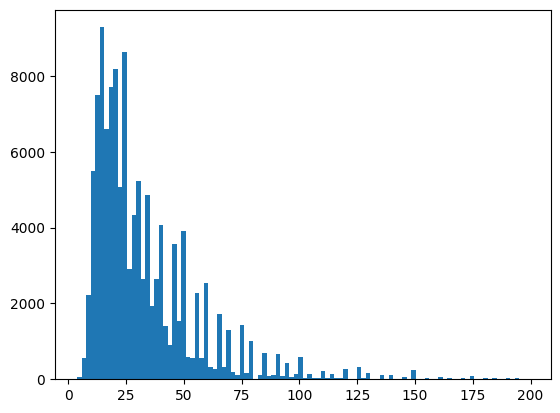

In [28]:
plt.hist(wine_reviews[wine_reviews["price"] < 200]["price"], bins = 100)

2. Imputar los valores faltantes en la columna `price` usando su valor medio.

In [29]:
wine_reviews_copia = wine_reviews.copy()
wine_reviews_copia.fillna(wine_reviews.price.mean(), inplace = True)

3. ¿Cambió el valor medio de la columna?¿Y su desviación estándar?¿Y los otros estadísticos que calculamos?¿Por qué?

In [30]:
print(wine_reviews_copia.price.mean())
print(wine_reviews_copia.price.mode()[0])
print(wine_reviews_copia.price.median())
print(wine_reviews_copia.price.std())

35.363389129985535
35.363389129985535
28.0
39.57706604502201


(array([15821., 36824., 23717., 23906., 10525.,  6252.,  3820.,  2763.,
         1675.,  1317.,   484.,   475.,   530.,   272.,   359.,    59.,
          134.,   130.,    62.,    70.]),
 array([  4.  ,  13.75,  23.5 ,  33.25,  43.  ,  52.75,  62.5 ,  72.25,
         82.  ,  91.75, 101.5 , 111.25, 121.  , 130.75, 140.5 , 150.25,
        160.  , 169.75, 179.5 , 189.25, 199.  ]),
 <BarContainer object of 20 artists>)

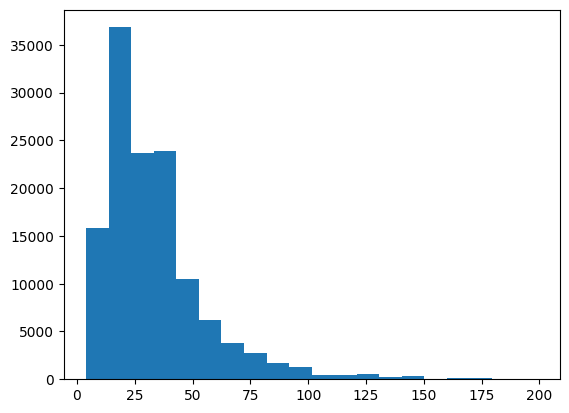

In [32]:
plt.hist(wine_reviews_copia[wine_reviews_copia["price"] < 200]["price"], bins = 20)

4. Volver a correr las celdas anteriores, pero completando los valores faltantes con la mediana y luego la moda.

5. Trabajar con un dataset sin visualizar es muy aburrido y, diríamos, casi frustrante. Mientras tanto, intenten hacer un histograma de los puntajes asignados y, luego, de los precios.

(array([  397.,   692.,  1836.,  3025.,  6480.,  9530., 12600., 16933.,
        17207., 12226., 15410., 11359.,  9613.,  6489.,  3758.,  1535.,
          523.,   229.,    77.,    52.]),
 array([ 80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,
         91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100.]),
 <BarContainer object of 20 artists>)

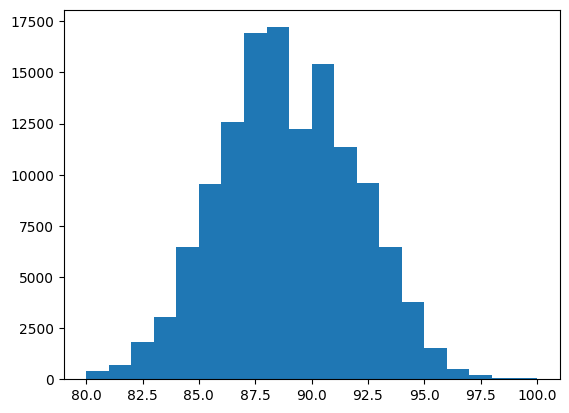

In [33]:
plt.hist(wine_reviews_copia["points"], bins = 20)

(array([  397.,   692.,  1836.,  3025.,  6480.,  9530., 12600., 16933.,
        17207., 12226., 15410., 11359.,  9613.,  6489.,  3758.,  1535.,
          523.,   229.,    77.,    52.]),
 array([ 80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,
         91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100.]),
 <BarContainer object of 20 artists>)

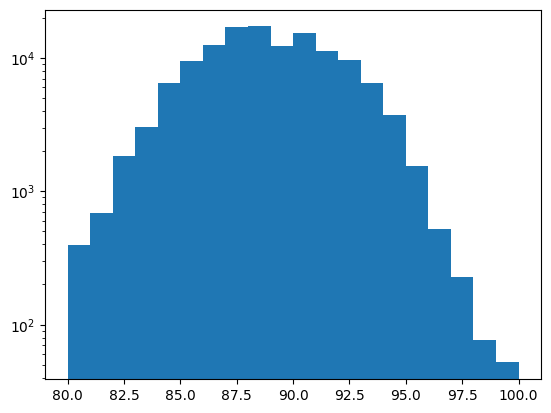

In [34]:
plt.hist(wine_reviews_copia["points"], bins = 20, log=True)

Permite visualizar mejor las diferencias en recuentos que varían en órdenes de magnitud.

Hace que las barras con frecuencias bajas sean más visibles, evitando que se "aplasten" debido a las barras con frecuencias muy altas.

Respecto al segundo gráfico, ¿les gusta cómo queda?¿Qué es una escala logarítmica?